# 230. MNIST Dataset 손글씨 인식 - LeNet

- CNN을 이용한 MNIST dataset 손글씨 인식  
- Yan LeCun이 1998년 발표한 LeNet-5을 PyTorch로 customize하여 재현

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

transforms.ToTensor()의 주요 특징:

1) 데이터 타입 변환: PIL 이미지나 NumPy ndarray를 torch.FloatTensor로 변환  
2) 스케일링: 이미지의 픽셀 값 범위를 [0, 255]에서 [0.0, 1.0]으로 스케일링  
3) 차원 재배열: PyTorch에서는 이미지 데이터를 [C, H, W] 형식(채널, 높이, 너비)으로 처리하므로 입력 이미지 데이터의 차원을 이 형식으로 자동으로 재배열

In [3]:
# transforms.Compose는 여러 변환(transform)을 함께 결합할 때 사용됩니다.
composed = transforms.Compose([
    # 이미지를 PyTorch 텐서로 변환하고 [0.0, 1.0]으로 스케일링
    transforms.ToTensor(),
    # 정규화를 수행합니다. MNIST 데이터셋의 표준 평균과 표준편차 사용
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
# 학습 데이터(train) 로드
train_data = dsets.MNIST(
    root='./data',        # 데이터를 저장할 경로
    train=True,           # 학습 데이터셋을 다운로드할지 여부 (True: 학습 데이터)
    download=True,        # 데이터가 없을 경우 자동으로 다운로드
    transform=composed    # 이미지 변환(transform) 적용 (예: 텐서 변환, 정규화 등)
)

# 테스트 데이터(test) 로드
test_data = dsets.MNIST(
    root='./data',        # 데이터를 저장할 경로
    train=False,          # 테스트 데이터셋을 다운로드할지 여부 (False: 테스트 데이터)
    download=True,        # 데이터가 없을 경우 자동으로 다운로드
    transform=composed    # 이미지 변환(transform) 적용
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


In [5]:
# train_data 객체 출력
print(train_data)
print()
# test_data 객체 출력
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


- Data 시각화

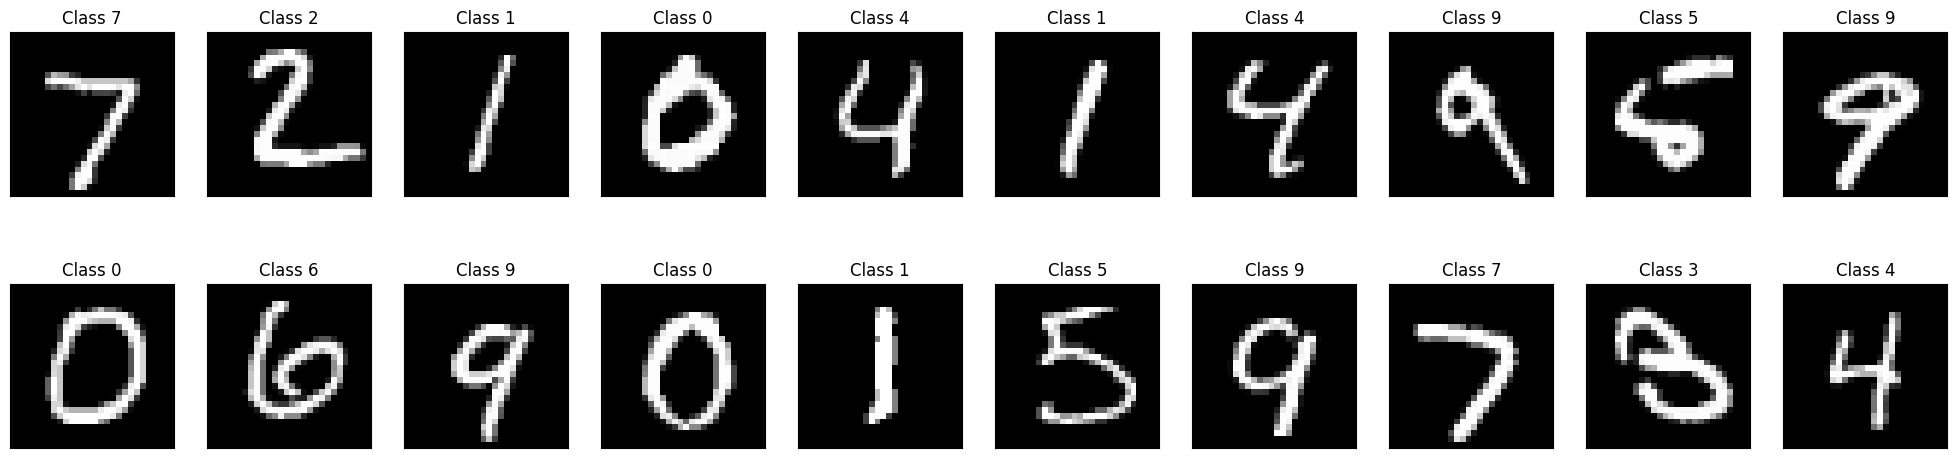

In [6]:
plt.figure(figsize=(25, 6))

# 테스트 데이터에서 20개의 이미지 출력
for i, (x, y) in enumerate(test_data):  # enumerate를 사용하여 이미지(x)와 레이블(y) 가져오기
    if i > 19:
        break

    # 서브플롯 생성 (2행 10열 배치, 현재 i번째 위치)
    plt.subplot(2, 10, i + 1)

    # 이미지를 28x28 크기로 변환하여 출력 (MNIST 데이터는 28x28 크기의 흑백 이미지)
    plt.imshow(x.numpy().reshape(28, 28), cmap='gray')

    # 이미지 제목 설정 (해당 숫자 클래스 표시)
    plt.title("Class {}".format(y))

    # x축, y축 눈금 제거 (불필요한 좌표 값 숨김)
    plt.xticks([])
    plt.yticks([])

plt.show()

### Dataset Loader 생성
- Train dataset과 Test dataset으로 2 분할

In [9]:
# 배치 크기(batch size) 설정
batch_size = 128

# DataLoader를 사용하여 미니배치 단위로 데이터 로딩
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)  # 훈련 데이터 (랜덤 섞기)
test_loader  = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)  # 테스트 데이터 (순차적 로딩)
len(train_loader), len(test_loader)

(469, 79)

## Model build

<img src="https://d2l.ai/_images/lenet.svg" width="800" />

In [11]:
# LeNet 모델 정의 (CNN 기반 신경망)
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()  # 부모 클래스(nn.Module) 초기화

        # 첫 번째 합성곱 계층 (입력 채널: 1, 출력 채널: 6, 커널 크기: 5, 패딩: 2)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(6)  # Batch Normalization 추가

        # 두 번째 합성곱 계층 (입력 채널: 6, 출력 채널: 16, 커널 크기: 5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(16)  # Batch Normalization 추가

        # 첫 번째 완전 연결층 (입력 크기: 16 * 5 * 5, 출력 크기: 120)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)

        # 두 번째 완전 연결층 (입력 크기: 120, 출력 크기: 84)
        self.fc2 = nn.Linear(120, 84)

        # 세 번째 완전 연결층 (입력 크기: 84, 출력 크기: 10) → 10개의 클래스 (0~9)
        self.fc3 = nn.Linear(84, 10)

        # 풀링 계층 (최대 풀링, 커널 크기: 2)
        self.maxpool = nn.MaxPool2d(2)

        # 활성화 함수 (ReLU)
        self.relu = nn.ReLU()

        # Batch Normalization과 Dropout 추가 (과적합 방지 및 학습 안정화)
        self.dropout = nn.Dropout(0.5)  # 드롭아웃 확률 50%

    # 순전파(Forward) 연산 정의
    def forward(self, x):
        x = self.conv1(x)             # 1st Conv
        x = self.bn1(x)                # Batch Normalization
        x = self.relu(x)               # ReLU
        x = self.maxpool(x)           # 1st MaxPooling

        x = self.conv2(x)              # 2nd Conv
        x = self.bn2(x)                 # Batch Normalization
        x = self.relu(x)               # ReLU
        x = self.maxpool(x)           # 2nd MaxPooling

        # 출력을 1차원으로 평탄화 (Flatten)
        x = torch.flatten(x, 1)

        x = self.relu(self.fc1(x))  # 1st Fully Connected → ReLU
        x = self.dropout(x)         # Dropout 적용

        x = self.relu(self.fc2(x))  # 2nd Fully Connected → ReLU
        x = self.dropout(x)         # Dropout 적용

        out = self.fc3(x)           # 3rd Fully Connected (출력층)

        return out  # 최종 출력 (10개 클래스에 대한 점수)

In [12]:
# LeNet 모델 객체 생성
model = LeNet()

# 모델 구조 출력
model

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

In [13]:
# train_loader에서 첫 번째 배치의 데이터(특성) 가져오기
first_batch_data = next(iter(train_loader))[0]

# 출력 형태 확인 [배치 크기, 채널 수, 높이, 너비]
print(first_batch_data.shape)

torch.Size([128, 1, 28, 28])


In [14]:
# 첫 번째 배치 데이터를 모델에 전달하여 순전파 수행
# 차원 계산 검증을 위한 상세 분석
sample_input = next(iter(train_loader))[0]
print(f"Input shape: {sample_input.shape}")

# 각 레이어별 출력 차원 계산
x = sample_input
print(f"Initial input: {x.shape}")

# Conv1: 1x28x28 -> 6x28x28 (padding=2로 인해 크기 유지)
x = model.conv1(x)
print(f"After Conv1: {x.shape}")

# MaxPool1: 6x28x28 -> 6x14x14
x = model.maxpool(x)
print(f"After MaxPool1: {x.shape}")

# Conv2: 6x14x14 -> 16x10x10 (padding 없음)
x = model.conv2(x)
print(f"After Conv2: {x.shape}")

# MaxPool2: 16x10x10 -> 16x5x5
x = model.maxpool(x)
print(f"After MaxPool2: {x.shape}")

# Flatten: 16x5x5 -> 400 (16*5*5 = 400)
x = torch.flatten(x, 1)
print(f"After Flatten: {x.shape}")

print(f"\nFC1 input size: {x.shape[1]} (should be 16*5*5 = 400)")
print(f"FC1 weight shape: {model.fc1.weight.shape}")

# 전체 모델 출력
output = model(sample_input)
print(f"Final output shape: {output.shape}")

Input shape: torch.Size([128, 1, 28, 28])
Initial input: torch.Size([128, 1, 28, 28])
After Conv1: torch.Size([128, 6, 28, 28])
After MaxPool1: torch.Size([128, 6, 14, 14])
After Conv2: torch.Size([128, 16, 10, 10])
After MaxPool2: torch.Size([128, 16, 5, 5])
After Flatten: torch.Size([128, 400])

FC1 input size: 400 (should be 16*5*5 = 400)
FC1 weight shape: torch.Size([120, 400])
Final output shape: torch.Size([128, 10])


### Model Summary

In [16]:
# 모델의 전체 파라미터 수 출력
print("Total parameters :", sum(p.numel() for p in model.parameters()))

Total parameters : 61750


### 손실 함수 (Loss Function)

- `nn.CrossEntropyLoss()`를 다중 분류 문제에 적용
- MNIST는 10개 클래스(0~9)를 분류하는 다중 분류 문제
- `nn.CrossEntropyLoss()`는 내부적으로 LogSoftmax + NLLLoss를 포함하므로 모델 출력이 logits일 때 바로 사용 가능

In [17]:
# 손실 함수 정의 (CrossEntropyLoss: 분류 문제에서 사용)
criterion = nn.CrossEntropyLoss()

# 모델을 지정한 장치(GPU 또는 CPU)로 이동
model.to(device)

# PyTorch 2.0에서 권장하는 `torch.compile()` 적용
model = torch.compile(model)
model

OptimizedModule(
  (_orig_mod): LeNet(
    (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=400, out_features=120, bias=True)
    (fc2): Linear(in_features=120, out_features=84, bias=True)
    (fc3): Linear(in_features=84, out_features=10, bias=True)
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (relu): ReLU()
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [18]:
# 학습률 설정
lr = 0.01

# SGD(확률적 경사 하강법) 옵티마이저 정의
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# 학습률 스케줄러 (5 에포크마다 학습률을 0.5배 감소)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [19]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """한 에포크 동안 모델을 훈련하는 함수"""
    model.train()
    train_loss = 0
    train_acc = 0
    total_samples = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        z = model(x)
        loss = criterion(z, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        y_pred = z.argmax(1)
        train_acc += (y_pred == y).sum().item()
        total_samples += y.size(0)

    return train_loss / len(train_loader), train_acc / total_samples

# 학습 실행
LOSS, ACC = [], []
EPOCHS = 10  # 총 에폭 수 설정

print("손실 함수: nn.CrossEntropyLoss() - 내부적으로 LogSoftmax + NLLLoss 포함")
print("-" * 60)

for epoch in range(EPOCHS):
    # 훈련
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # 학습률 업데이트
    scheduler.step()

    # 결과 저장
    LOSS.append(train_loss)
    ACC.append(train_acc)

    # 에폭별 훈련 결과 출력
    print(f'epoch {epoch} ==> train loss: {train_loss:.5f}, train acc: {train_acc:.5f}')

print("\n=== 학습 완료 ===")
print("CrossEntropyLoss를 통한 다중 분류 학습이 성공적으로 완료되었습니다!")

손실 함수: nn.CrossEntropyLoss() - 내부적으로 LogSoftmax + NLLLoss 포함
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
W0125 03:02:40.726000 1369 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode


epoch 0 ==> train loss: 1.70232, train acc: 0.44355
epoch 1 ==> train loss: 0.68656, train acc: 0.79033
epoch 2 ==> train loss: 0.41673, train acc: 0.87802
epoch 3 ==> train loss: 0.31581, train acc: 0.91047
epoch 4 ==> train loss: 0.26350, train acc: 0.92650
epoch 5 ==> train loss: 0.22816, train acc: 0.93635
epoch 6 ==> train loss: 0.21437, train acc: 0.94018
epoch 7 ==> train loss: 0.20148, train acc: 0.94465
epoch 8 ==> train loss: 0.19287, train acc: 0.94678
epoch 9 ==> train loss: 0.18253, train acc: 0.94927

=== 학습 완료 ===
CrossEntropyLoss를 통한 다중 분류 학습이 성공적으로 완료되었습니다!


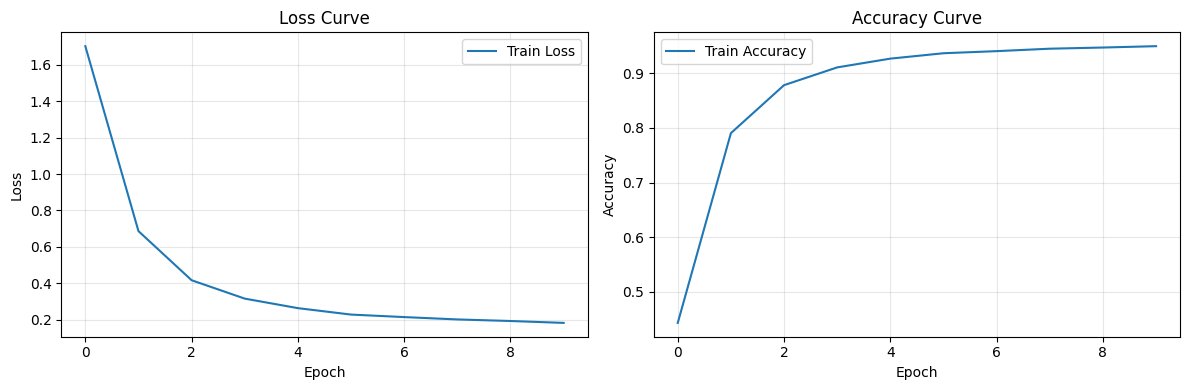

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 훈련 손실 그래프
ax1.plot(LOSS, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss Curve')
ax1.grid(True, alpha=0.3)  # 격자 추가

# 훈련 정확도 그래프
ax2.plot(ACC, label='Train Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy Curve')
ax2.grid(True, alpha=0.3)  # 격자 추가

plt.tight_layout()
plt.show()

## Model 평가 - Test set 사용

In [21]:
# 모델 평가 - 테스트 세트 사용

predictions = []  # 모델의 예측을 저장할 리스트
labels = []  # 실제 레이블을 저장할 리스트

model.eval()  # 모델을 평가 모드로 설정

print("=== 테스트 세트 평가 ===")
print("CrossEntropyLoss로 학습한 모델의 최종 성능 평가")

# 테스트 로더를 통해 테스트 데이터셋의 배치를 순회
with torch.inference_mode():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)  # 데이터를 현재 디바이스(CPU 또는 GPU)로 이동
        z = model(x)  # 모델에 데이터를 전달하여 예측값(z) 계산 - logits 출력
        y_pred = z.argmax(1) # 예측값 중 가장 높은 값을 가진 인덱스 추출

        # 예측 결과와 실제 레이블을 CPU로 이동 후 numpy 배열로 변환하여 리스트에 추가
        predictions.extend(y_pred.numpy(force=True))
        labels.extend(y.numpy(force=True))

# 예측값과 실제 레이블이 일치하는 인덱스 추출
correct_indices = np.nonzero(np.array(predictions) == np.array(labels))[0]
# 예측값과 실제 레이블이 일치하지 않는 인덱스 추출
incorrect_indices = np.nonzero(np.array(predictions) != np.array(labels))[0]

# 정확도 계산: 정확한 예측의 수를 전체 예측의 수로 나눈 후 백분율로 변환
print("accuracy = {:.2f}%".format(len(correct_indices) / len(predictions) * 100))
print(f"총 테스트 샘플: {len(predictions)}")
print(f"정확한 예측: {len(correct_indices)}")
print(f"잘못된 예측: {len(incorrect_indices)}")

=== 테스트 세트 평가 ===
CrossEntropyLoss로 학습한 모델의 최종 성능 평가
accuracy = 97.71%
총 테스트 샘플: 10000
정확한 예측: 9771
잘못된 예측: 229


# 실습: Fashion MNIST를 이용하여 위와 동일한 작업

Label	Class

0	T-shirt/top  
1	Trouser  
2	Pullover  
3	Dress  
4	Coat  
5	Sandal  
6	Shirt  
7	Sneaker  
8	Bag  
9	Ankle boot

In [23]:
composed = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize((0.1,), (0.3,))])

In [24]:
# Fashion MNIST 데이터 로드
train_data = dsets.FashionMNIST(root='./data', train=True, download=True, transform=composed)

test_data = dsets.FashionMNIST(root='./data', train=False, download=True, transform=composed)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 186kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


In [25]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

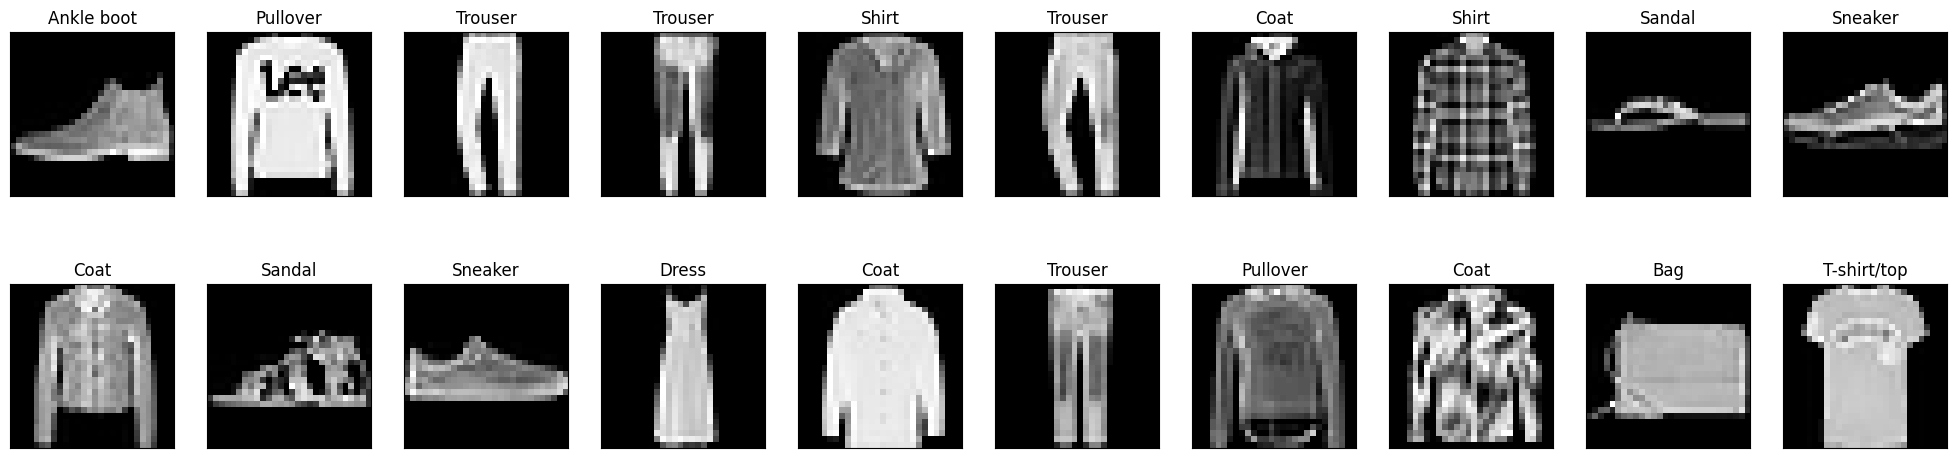

In [26]:
plt.figure(figsize=(25, 6))
for i, (x, y) in enumerate(test_data):
    if i > 19:
        break
    plt.subplot(2, 10, i+1)
    plt.imshow(x.numpy().reshape(28, 28), cmap='gray')
    plt.title(class_names[y])
    plt.xticks([])
    plt.yticks([])

plt.show()

# 실습 가이드: Fashion MNIST 분류 모델 구현

"""
다음 단계를 따라 Fashion MNIST 분류 모델을 구현해보세요:

1. 데이터 로더 생성
   - train_data와 test_data를 train/validation으로 분할
   - DataLoader 생성 (batch_size=128)

2. 모델 정의
   - 위에서 정의한 LeNet 클래스 재사용
   - 또는 새로운 아키텍처 시도

3. 학습 설정
   - 손실 함수: nn.CrossEntropyLoss()
   - 옵티마이저: SGD 또는 Adam
   - 학습률 스케줄러 설정

4. 학습 실행
   - 10 에포크 학습
   - 훈련/검증 손실 및 정확도 추적

5. 평가
   - 테스트 정확도 계산
   - 혼동 행렬 시각화
   - 클래스별 정확도 분석

6. 결과 비교
   - MNIST vs Fashion MNIST 성능 비교
   - 어떤 클래스가 가장 어려운지 분석
"""